# Kokaji liver: a genome-wide glucose response, in two genotypes

Wild-type and leptin-deficient obese (ob/ob) mouse liver, sampled at 0, 20,
60, 120 and 240 minutes after an oral glucose bolus. The transcriptome covers
14,292 genes and the metabolome 162 compounds, both with the authors' own fold
changes, q-values and half-response times, and eleven signalling proteins were
measured by western blot.

`obese_liver.py` scores three claims from this study on a 19-gene panel at one
timepoint and has to mark them "not reproduced here". This notebook uses the
study's own data, so the same claims can be tested with the right instrument.

Two things here exist nowhere else in this documentation: the transcription
factor inference is scored against a published inference on the same data, and
the metabolite axis is made quantitative with measured enzyme affinities.

The measurements belong to Kokaji *et al.*, *Science Signaling*
13(660):eaaz1236, 2020. They are downloaded at run time into a directory that
is not part of this repository and never redistributed.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from transnet import (
    build_name_id_map,
    compare_transomic_networks,
    convergence_significance,
    cross_layer_connectivity,
    downstream_influence,
    layer_coverage,
    map_omics_to_network,
    metabolite_regulatory_roles,
    reaction_regulation_table,
    regulation_axis_summary,
    regulatory_motifs,
    regulatory_role_enrichment,
    responsive_subnetwork,
    structural_vulnerability,
    trace_regulatory_paths,
    transcription_factor_activity,
    transomic_hubs,
)
from transnet.analysis import hub_rankings, path_verdicts, versus_chance
from transnet.datasets import (
    DATA_DIR,
    KOKAJI_TIMEPOINTS,
    fetch_kokaji_tables,
    kokaji_contrast,
    load_kokaji_table,
)
from transnet.io import read_network

warnings.filterwarnings("ignore", category=RuntimeWarning)

OUT = DATA_DIR / "published_results" / "kokaji_liver"
OUT.mkdir(parents=True, exist_ok=True)
TIMEPOINT = 240
LOG2FC_THRESHOLD = 0.585        # 1.5-fold, as the Kuroda laboratory defines it
QVALUE_THRESHOLD = 0.1

fetch_kokaji_tables()
source = DATA_DIR / "mouse" / "latest"
network = read_network(str(source / "interactions.csv"),
                       nodes_file=str(source / "nodes.csv"))
print(f"{network.number_of_nodes():,} molecules, "
      f"{network.number_of_edges():,} relationships")

106,859 molecules, 1,938,789 relationships


In [2]:
connectivity = cross_layer_connectivity(network)
print(f"{connectivity['cross_layer_fraction']:.0%} of edges cross between layers")
connectivity["matrix"]

82% of edges cross between layers


,Transcriptome,Proteome,Reactions,Metabolome
Transcriptome,0,17126,0,0
Proteome,1496009,355312,32899,0
Reactions,0,0,0,8133
Metabolome,0,0,29310,0


## The contrasts

Nothing is recomputed. The supplement gives a fold change, p-value and q-value
per timepoint per genotype, so the contrast is read off it and converted from a
ratio to log2. What differs between this analysis and the paper is the network
reading, not the statistics.

Metabolites arrive with KEGG compound ids, which is unusual and useful: no name
matching is needed for the layer that name matching usually limits.

In [3]:
contrasts = {}
for genotype in ("WT", "ob/ob"):
    contrasts[genotype] = {
        "Metabolome": kokaji_contrast("S1", genotype, TIMEPOINT),
        "Transcriptome": kokaji_contrast("S4", genotype, TIMEPOINT),
    }

pd.DataFrame([
    {"genotype": genotype, "layer": layer, "features": len(table),
     "q <= 0.1": int((table["padj"] <= QVALUE_THRESHOLD).sum()),
     "and 1.5-fold": int(((table["padj"] <= QVALUE_THRESHOLD)
                          & (table["log2FC"].abs() >= LOG2FC_THRESHOLD)).sum())}
    for genotype, tables in contrasts.items() for layer, table in tables.items()
]).set_index(["genotype", "layer"])

features  q <= 0.1  and 1.5-fold
genotype layer                                          
WT       Metabolome          162        36            26
         Transcriptome     14292       425           284
ob/ob    Metabolome          162        11             8
         Transcriptome     14292       552           399

The first result is visible before any network: at 240 minutes the wild-type
metabolome moves more than the obese one (36 metabolites against 11), while the
obese transcriptome moves more than the wild-type one (552 genes against 425).
That is the paper's headline, and it comes out of the raw contrast.

## Identifiers

Genes are Ensembl and the network is keyed by Entrez. The map is thousands of
lookups, so it is cached.

In [4]:
def cached_map(name, features, from_type, to_type):
    path = OUT / f"idmap_{name}.json"
    if path.exists():
        return json.loads(path.read_text())
    from transnet.analysis import id_mapping
    mapped = id_mapping(pd.DataFrame({"feature": sorted(features)}), id_col="feature",
                        from_type=from_type, to_type=to_type, organism="mouse")
    column = f"{to_type}_id"
    result = {k: str(v) for k, v in zip(mapped["feature"], mapped[column])
              if pd.notna(v)}
    path.write_text(json.dumps(result))
    return result


genes = set(contrasts["WT"]["Transcriptome"]["feature"])
metabolite_ids = set(contrasts["WT"]["Metabolome"]["feature"])
id_map = {
    "Transcriptome": cached_map("ensembl_to_entrez", genes, "ensembl.gene", "entrezgene"),
    "Metabolome": {i: i for i in metabolite_ids},      # already KEGG compounds
}
{layer: len(m) for layer, m in id_map.items()}

{'Transcriptome': 13413, 'Metabolome': 162}

## A network per genotype

In [5]:
graphs, reports = {}, []
for genotype, tables in contrasts.items():
    graph = network.copy()
    report = map_omics_to_network(
        graph, tables, id_column="feature", log2fc_column="log2FC",
        qvalue_column="padj", id_map=id_map,
        qvalue_threshold=QVALUE_THRESHOLD, log2fc_threshold=LOG2FC_THRESHOLD,
    )
    graphs[genotype] = graph
    reports.append(report.per_layer.assign(genotype=genotype))

pd.concat(reports)[["genotype", "layer", "n_supplied", "n_matched",
                    "match_fraction", "n_up", "n_down"]].reset_index(drop=True)

,genotype,layer,n_supplied,n_matched,match_fraction,n_up,n_down
0,WT,Metabolome,162,162,1.000000,25,1
1,WT,Transcriptome,14292,14024,0.981248,362,647
2,ob/ob,Metabolome,162,162,1.000000,8,0
3,ob/ob,Transcriptome,14292,14024,0.981248,413,642


In [6]:
layer_coverage(graphs["WT"])

,layer,n_nodes,n_measured,measured_fraction,n_responsive,n_regulated,n_up,n_down,mean_degree
0,Transcriptome,57540,14023,0.243709,1009,1009,362,647,26.297098
1,Proteome,17283,0,0.000000,0,0,0,0,130.570966
2,Reactions,12384,0,0.000000,0,0,0,0,5.680071
3,Metabolome,19652,162,0.008243,26,26,25,1,1.905302


## Which axis regulates each reaction

There is no proteome here, so the enzyme axis rests on transcripts alone.
`gene_axis_evidence` records that, and it is why these counts are not
comparable with a study that measured proteins.

In [7]:
regulation, rows = {}, []
for genotype, graph in graphs.items():
    table = reaction_regulation_table(graph)
    regulation[genotype] = table
    regulated = table[(table["gene_axis"] != 0) | (table["metabolite_axis"] != 0)]
    rows.append({
        "genotype": genotype,
        "regulated": len(regulated),
        "enzyme only": int(((regulated["gene_axis"] != 0)
                            & (regulated["metabolite_axis"] == 0)).sum()),
        "metabolite only": int(((regulated["gene_axis"] == 0)
                                & (regulated["metabolite_axis"] != 0)).sum()),
        "both": int(((regulated["gene_axis"] != 0)
                     & (regulated["metabolite_axis"] != 0)).sum()),
        "controversial": int(regulated["controversial"].sum()),
    })
    table.to_csv(OUT / f"reaction_regulation_{genotype.replace('/', '')}.csv",
                 index=False)

axes = pd.DataFrame(rows).set_index("genotype")
axes

,regulated,enzyme only,metabolite only,both,controversial
genotype,,,,,
WT,1202,790,304,108,62
ob/ob,844,756,75,13,8


This is the claim the paper is built on, and the 19-gene panel in
`obese_liver.py` could not test it: healthy liver answers glucose through
metabolites, obese liver through gene expression. Here the whole liver is
available and the two axes can be counted in each genotype.

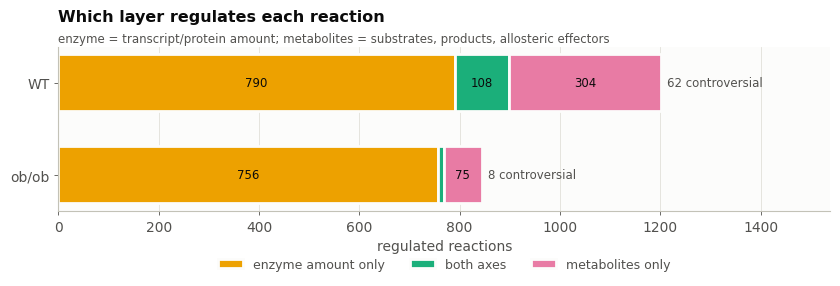

In [8]:
from transnet.visualization import plot_axis_composition

composition = pd.DataFrame([
    {"contrast": genotype,
     "enzyme_axis_only": row["enzyme only"],
     "metabolite_axis_only": row["metabolite only"],
     "both_axes": row["both"],
     "controversial": row["controversial"]}
    for genotype, row in axes.iterrows()
])
plot_axis_composition(composition)
plt.show()

## Per-pathway balance, and the metabolites doing the regulating

In [9]:
pd.concat([regulation_axis_summary(t).assign(genotype=g)
           for g, t in regulation.items()]).set_index("genotype")

,pathway,n_reactions,gene_activated,gene_inhibited,metabolite_activated,metabolite_inhibited,n_controversial,fraction_controversial,fraction_gene_driven,fraction_metabolite_driven
genotype,,,,,,,,,,
WT,all,1202,305,593,170,242,62,0.051581,0.747088,0.342762
ob/ob,all,844,372,397,33,55,8,0.009479,0.911137,0.104265


In [10]:
role_rows = []
for genotype, graph in graphs.items():
    result = regulatory_role_enrichment(metabolite_regulatory_roles(graph))
    counts = result["counts"]
    row = result["enrichment"].set_index("role").loc["any"]
    role_rows.append({
        "genotype": genotype,
        "changed metabolites": counts["n_differential"],
        "of those regulators": counts["n_differential_regulators"],
        "background share": round(counts["fraction_background_regulators"], 3),
        "q": round(float(row["q_value"]), 3),
    })
pd.DataFrame(role_rows).set_index("genotype")

,changed metabolites,of those regulators,background share,q
genotype,,,,
WT,26,14,0.488,0.544
ob/ob,8,3,0.488,0.845


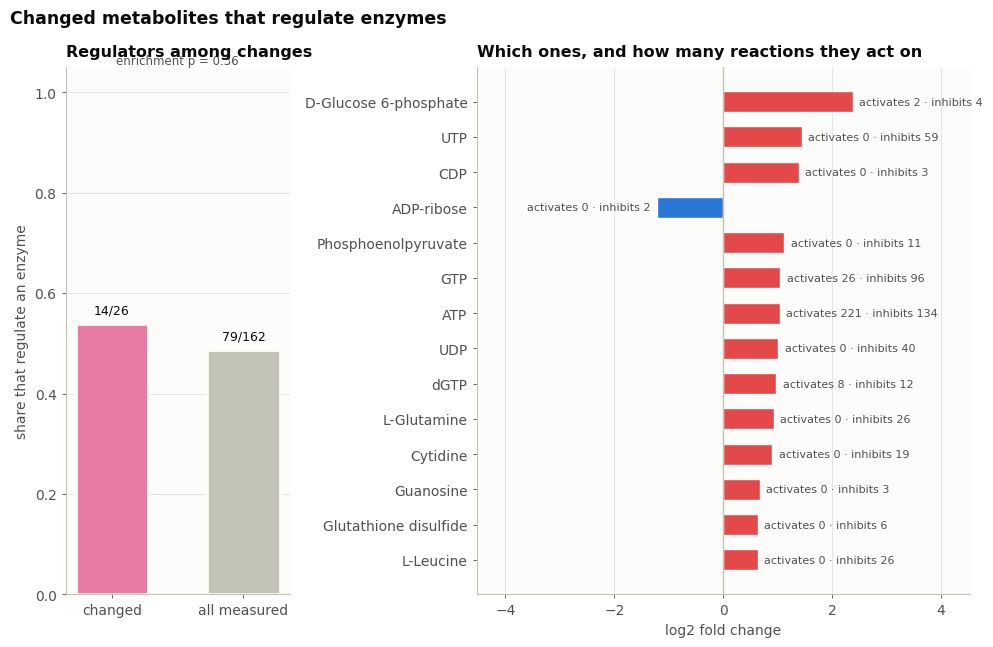

In [11]:
from transnet.visualization import plot_metabolite_regulators

regulator_figure = plot_metabolite_regulators(
    regulatory_role_enrichment(metabolite_regulatory_roles(graphs["WT"])))
plt.show()

## Saturation, and the currency metabolites

A metabolite can be an annotated regulator of an enzyme and still be irrelevant
to it if its concentration sits far from the affinity. Table S13 gives measured
Km and Ki values with a saturation index per genotype, for ATP and NADP+.

Those two are exactly what TransNet treats as *currency* metabolites and
excludes from the metabolite axis, on the grounds that everything uses them and
a change in ATP is not a regulatory statement about any particular reaction.
The saturation index tests that decision rather than assuming it: if these
enzymes are already near-saturated for ATP, then ATP moving changes nothing,
and excluding it is right.

In [12]:
kinetics = load_kokaji_table("S13", sheet="Km, Ki (ATP, NADP+)", header_rows=1)
kinetics = kinetics.assign(
    wt=pd.to_numeric(kinetics["Saturation index of WT mice at 0min"], errors="coerce"),
    obese=pd.to_numeric(kinetics["Saturation index of ob/ob mice at 0min"],
                        errors="coerce"),
).dropna(subset=["wt", "obese"])

print(f"{len(kinetics)} enzyme-metabolite pairs with a measured constant")
kinetics.groupby(["Km or Ki", "Metabolite"])[["wt", "obese"]].mean().round(3)

93 enzyme-metabolite pairs with a measured constant


wt  obese
Km or Ki Metabolite              
Ki       ATP         0.165  0.416
Km       ATP         0.711  0.869
         NADP+       0.825  0.818

A saturation index near 1 means the enzyme is saturated, so a further rise in
that metabolite changes nothing. Comparing the genotypes says whether obesity
moves an enzyme into or out of the range where its regulator still has an
effect.

In [13]:
shifted = kinetics.assign(shift=kinetics["obese"] - kinetics["wt"])
shifted.nlargest(8, "shift")[["Km or Ki", "Metabolite", "EC number",
                              "Geometric mean", "wt", "obese", "shift"]]

,Km or Ki,Metabolite,EC number,Geometric mean,wt,obese,shift
78,Ki,ATP,2.7.7.4,1.048809,0.323341,0.668620,0.345278
12,Km,ATP,2.7.4.8,1,0.333854,0.679092,0.345238
4,Km,ATP,2.7.1.48,1.134938,0.306320,0.650906,0.344587
56,Km,ATP,2.7.6.2,1.2,0.294605,0.638136,0.343531
59,Km,ATP,3.6.1.3,0.88,0.362861,0.706291,0.343430
17,Km,ATP,6.2.1.3,1.4,0.263613,0.601838,0.338226
79,Ki,ATP,2.7.8.11,1.4,0.263613,0.601838,0.338226
14,Km,ATP,2.7.9.3,0.75,0.400563,0.738326,0.337763


Two aggregate means would hide the shape of this. Every pair, with the
diagonal: a point above the line is an enzyme sitting closer to saturation in
obese liver, where a further change in that metabolite has less effect.

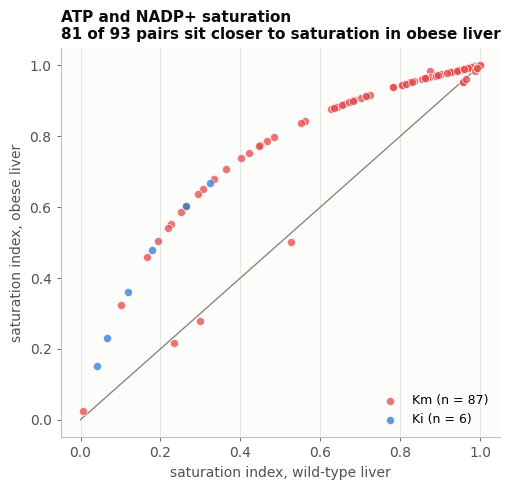

In [14]:
from transnet.visualization.palette import DOWN, INK, MUTED, SURFACE, UP, style_axes

saturation_figure, saturation_axes = plt.subplots(figsize=(5.2, 5))
saturation_axes.plot([0, 1], [0, 1], color=MUTED, linewidth=1, zorder=1)
for constant, colour in (("Km", UP), ("Ki", DOWN)):
    subset = shifted[shifted["Km or Ki"] == constant]
    saturation_axes.scatter(subset["wt"], subset["obese"], s=34, alpha=0.75,
                            color=colour, edgecolor=SURFACE, linewidth=0.6,
                            label=f"{constant} (n = {len(subset)})", zorder=2)
above = int((shifted["shift"] > 0).sum())
saturation_axes.set_xlabel("saturation index, wild-type liver")
saturation_axes.set_ylabel("saturation index, obese liver")
saturation_axes.set_title(
    f"ATP and NADP+ saturation\n{above} of {len(shifted)} pairs sit closer to "
    f"saturation in obese liver", loc="left", fontsize=11, fontweight="bold",
    color=INK)
saturation_axes.legend(frameon=False, fontsize=9, loc="lower right")
style_axes(saturation_axes)
saturation_figure.tight_layout()
plt.show()

The same pairs, matched to the reactions the network regulated, so the
saturation index attaches to a regulation call rather than to an EC number on
its own.

In [15]:
# The EC number sits on the catalysis edge, not on the reaction node, because one
# reaction can be catalysed by enzymes of more than one EC class.
reaction_ec = {}
for enzyme, reaction, data in graphs["WT"].edges(data=True):
    if data.get("edge_type") != "catalysis":
        continue
    for ec in str(data.get("ec") or "").split(","):
        ec = ec.strip()
        if ec:
            reaction_ec.setdefault(reaction, set()).add(ec)

ec_saturation = (shifted.groupby(shifted["EC number"].astype(str).str.strip())
                 [["wt", "obese", "shift"]].mean().round(3))

rows = []
for reaction, ecs in reaction_ec.items():
    matched = [ec for ec in ecs if ec in ec_saturation.index]
    if not matched:
        continue
    row = regulation["WT"].loc[regulation["WT"]["reaction"] == reaction]
    if row.empty:
        continue
    row = row.iloc[0]
    if row["gene_axis"] == 0 and row["metabolite_axis"] == 0:
        continue
    values = ec_saturation.loc[matched].mean()
    rows.append({"reaction": reaction, "name": str(row["name"])[:44],
                 "ec": ", ".join(sorted(matched)),
                 "gene_axis": row["gene_axis"],
                 "metabolite_axis": row["metabolite_axis"],
                 "wt": round(values["wt"], 3), "obese": round(values["obese"], 3),
                 "shift": round(values["shift"], 3)})

regulated_with_kinetics = pd.DataFrame(rows)
print(f"{len(regulated_with_kinetics)} regulated reactions have a measured "
      f"saturation index")
regulated_with_kinetics.sort_values("shift", key=abs, ascending=False).head(10)

87 regulated reactions have a measured saturation index


,reaction,name,ec,gene_axis,metabolite_axis,wt,obese,shift
85,R08232,ATP:5-fluorouridine 5'-phosphotransferase; 5,2.7.1.48,0,-1,0.306,0.651,0.345
84,R00968,GTP:uridine 5'-phosphotransferase; GTP + Uri,2.7.1.48,0,-1,0.306,0.651,0.345
83,R00964,ATP:uridine 5'-phosphotransferase; ATP + Uri,2.7.1.48,0,-1,0.306,0.651,0.345
82,R00517,GTP:cytidine 5'-phosphotransferase; GTP + Cy,2.7.1.48,0,-1,0.306,0.651,0.345
81,R00513,ATP:cytidine 5'-phosphotransferase; ATP + Cy,2.7.1.48,0,-1,0.306,0.651,0.345
68,R12852,guanylate kinase; dZMP + ATP <=> dZDP + ADP,2.7.4.8,0,-1,0.334,0.679,0.345
67,R02090,ATP:dGMP phosphotransferase; ATP + dGMP <=>,2.7.4.8,0,-1,0.334,0.679,0.345
66,R00332,ATP:GMP phosphotransferase; ATP + GMP <=> AD,2.7.4.8,0,-1,0.334,0.679,0.345
0,R00390,long-chain-fatty-acid:CoA ligase (AMP-formin,6.2.1.3,-1,0,0.264,0.602,0.338
1,R01280,palmitate:CoA ligase (AMP-forming); ATP + He,6.2.1.3,-1,0,0.264,0.602,0.338


## Transcription factors, against a published inference

Every other transcription-factor result in this documentation is unvalidated:
the ranking looks plausible and nothing says whether it is right. Here the
authors inferred factors from the same transcriptome by motif enrichment over
gene clusters (Table S7), so the two inferences can be compared.

They are not the same method. Motif enrichment asks which sequences are
over-represented in a cluster's promoters; `transcription_factor_activity` asks
which ChIP-Atlas-bound target sets are over-represented among responsive genes.
Agreement between two different methods on one dataset is worth more than
either alone.

In [16]:
activity = {}
for genotype, graph in graphs.items():
    table = transcription_factor_activity(graph, min_targets=5)
    activity[genotype] = table
    implicated = table[table["q_value"] <= 0.05] if not table.empty else table
    print(f"{genotype:<6} {len(implicated)} of {len(table)} factors implicated "
          f"at q <= 0.05")

activity["WT"].head(12)[["name", "n_targets", "n_responsive_targets", "n_up",
                         "n_down", "q_value", "inferred_activity",
                         "factor_regulated"]]

WT     10 of 708 factors implicated at q <= 0.05


ob/ob  9 of 708 factors implicated at q <= 0.05


,name,n_targets,n_responsive_targets,n_up,n_down,q_value,inferred_activity,factor_regulated
0,Jarid2,1101,172,69,103,7.389843e-21,0,None
1,Suz12,930,146,58,88,9.986667e-18,0,None
2,Cbx7,851,136,55,81,3.239382e-17,0,None
3,Rnf2,1764,216,92,124,4.136176e-14,0,None
4,Mtf2,642,100,45,55,1.109390e-11,0,None
5,Eed,440,75,31,44,1.651585e-10,0,None
6,Pcgf2,792,111,45,66,3.935012e-10,0,None
7,Ezh2,249,41,16,25,4.235599e-05,0,None
8,Bmi1,76,16,8,8,6.424744e-03,0,None
9,Phc1,179,27,13,14,1.371096e-02,0,None


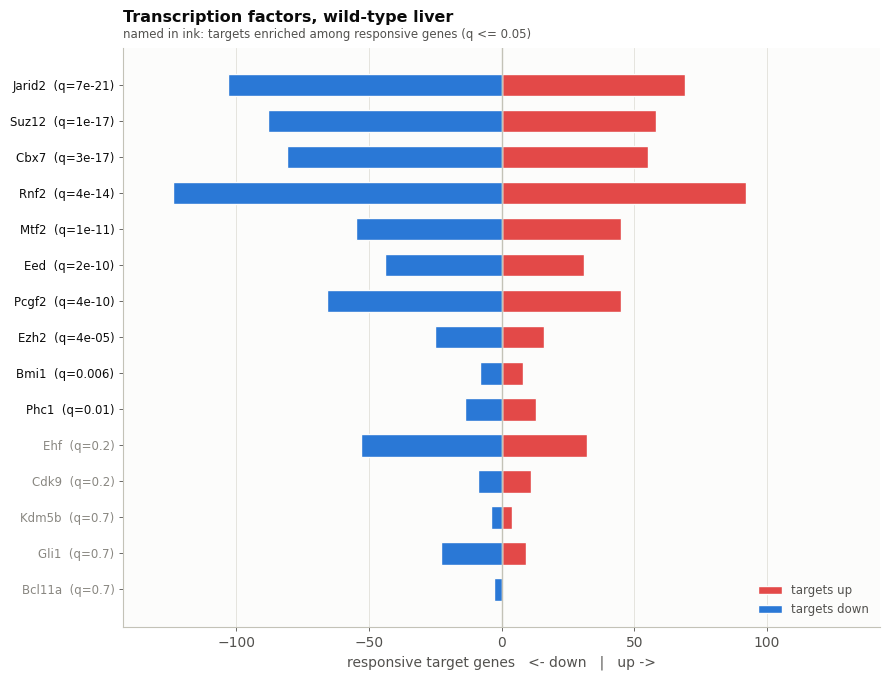

In [17]:
from transnet.visualization import plot_tf_activity

tf_figure = plot_tf_activity(activity["WT"],
                             title="Transcription factors, wild-type liver")
plt.show()

In [18]:
motifs_published = load_kokaji_table("S7", sheet="Motif")
enriched_columns = [c for c in motifs_published.columns if "isEnrichedMotif" in c]
enriched_mask = motifs_published[enriched_columns].apply(
    pd.to_numeric, errors="coerce").fillna(0).gt(0).any(axis=1)
their_factors = set(motifs_published.loc[enriched_mask, "Name"].astype(str).str.upper())
print(f"the authors call {len(their_factors)} motifs enriched in at least one "
      f"gene cluster, out of {len(motifs_published)} tested")

ours = activity["WT"]
ours_implicated = set(ours.loc[ours["q_value"] <= 0.05, "name"]
                      .astype(str).str.upper())
ours_tested = set(ours["name"].astype(str).str.upper())
shared = their_factors & ours_tested

pd.DataFrame([
    {"in both analyses": len(shared),
     "they call enriched, we test": len(their_factors & ours_tested),
     "we implicate and they do too": len(ours_implicated & their_factors),
     "we implicate, they do not": len(ours_implicated - their_factors),
     "they implicate, we do not": len(their_factors & ours_tested
                                      - ours_implicated)}
])

the authors call 37 motifs enriched in at least one gene cluster, out of 120 tested


,in both analyses,"they call enriched, we test",we implicate and they do too,"we implicate, they do not","they implicate, we do not"
0,14,14,0,10,14


In [19]:
sorted(ours_implicated & their_factors)

[]

## Timing, against the authors' own half-response times

Every other timing result here uses half-response times this package computed.
The supplement distributes them, per genotype, for both layers, so the
degree-versus-timing question can be asked with the paper's own numbers.

In [20]:
timing = []
for genotype in ("WT", "ob/ob"):
    for layer, table in (("Metabolome", "S1"), ("Transcriptome", "S4")):
        contrast = kokaji_contrast(table, genotype, TIMEPOINT)
        if "t_half" not in contrast:
            continue
        timed = contrast.dropna(subset=["t_half"])
        timing.append({"genotype": genotype, "layer": layer,
                       "with a t-half": len(timed),
                       "median t-half (min)": round(timed["t_half"].median(), 1)})
pd.DataFrame(timing).set_index(["genotype", "layer"])

with a t-half  median t-half (min)
genotype layer                                            
WT       Metabolome                64                 13.2
         Transcriptome           1255                 26.8
ob/ob    Metabolome                46                 14.7
         Transcriptome           2511                 15.9

Morita *et al.* report that in healthy liver the best-connected molecules
respond first, and that the relationship is lost in obesity. The same test, on
the authors' t-half values and this network's degrees:

In [21]:
from scipy import stats

degree_timing = []
for genotype, graph in graphs.items():
    for layer, table in (("Metabolome", "S1"), ("Transcriptome", "S4")):
        contrast = kokaji_contrast(table, genotype, TIMEPOINT)
        if "t_half" not in contrast:
            continue
        mapped = contrast.assign(
            node=contrast["feature"].map(lambda f: id_map[layer].get(f, f)))
        mapped = mapped[mapped["node"].isin(graph)].dropna(subset=["t_half"])
        if len(mapped) < 10:
            continue
        degrees = mapped["node"].map(dict(graph.degree()))
        rho, p = stats.spearmanr(degrees, mapped["t_half"])
        degree_timing.append({"genotype": genotype, "layer": layer,
                              "n": len(mapped), "rho": round(rho, 3),
                              "p": float(f"{p:.3g}")})
pd.DataFrame(degree_timing).set_index(["genotype", "layer"])

n    rho       p
genotype layer                             
WT       Metabolome       64 -0.000  0.9990
         Transcriptome  1238 -0.018  0.5340
ob/ob    Metabolome       46 -0.156  0.3020
         Transcriptome  2484 -0.034  0.0919

## Hubs

In [22]:
hub_tables = {}
for genotype, graph in graphs.items():
    hubs, without_binding, binding_share = hub_rankings(graph, top_percent=2)
    hub_tables[genotype] = hubs
    print(f"{genotype:<6} " + ", ".join(hubs.head(3)["name"].str[:34]))

hub_tables["WT"].head(10)[["name", "layer", "cross_layer_degree",
                           "n_layers_touched"]]

WT     ATP; Adenosine 5'-triphosphate, GTP; Guanosine 5'-triphosphate, UTP; Uridine 5'-triphosphate; Urid
ob/ob  D-Fructose 6-phosphate; D-Fructose, D-Glucose 6-phosphate; Glucose 6-p


,name,layer,cross_layer_degree,n_layers_touched
0,ATP; Adenosine 5'-triphosphate,Metabolome,196,1
1,GTP; Guanosine 5'-triphosphate,Metabolome,117,1
2,UTP; Uridine 5'-triphosphate; Uridine triphosp...,Metabolome,66,1
3,UDP; Uridine 5'-diphosphate,Metabolome,41,1
4,L-Glutamine; L-2-Aminoglutaramic acid,Metabolome,38,1
5,L-Leucine; 2-Amino-4-methylvaleric acid; (2S)-...,Metabolome,27,1
6,Cytidine,Metabolome,22,1
7,Phosphoenolpyruvate; Phosphoenolpyruvic acid; PEP,Metabolome,18,1
8,dGTP; 2'-Deoxyguanosine 5'-triphosphate; Deoxy...,Metabolome,15,1
9,CDP; Cytidine 5'-diphosphate; Cytidine diphosp...,Metabolome,9,1


## Signed paths and propagation

In [23]:
traced, traced_paths, path_rows = {}, {}, []
for genotype, graph in graphs.items():
    paths = trace_regulatory_paths(graph, target_layer="Metabolome", max_length=4,
                                   max_paths=20000)
    summary, agree_paths, tested_paths = path_verdicts(paths)
    traced[genotype] = (summary, agree_paths, tested_paths)
    traced_paths[genotype] = paths
    seeds = {n: float(d["log2fc"]) for n, d in graph.nodes(data=True)
             if d.get("layer") == "Transcriptome" and d.get("regulated")
             and d.get("log2fc") is not None}
    influence = downstream_influence(graph, seeds, target_layer="Metabolome")
    measured = influence[influence["observed"].fillna(0) != 0]
    agree = int(measured["agrees"].astype("boolean").fillna(False).sum())
    path_rows.append({
        "genotype": genotype,
        "paths": len(paths),
        "metabolites the paths score": tested_paths,
        "paths predict correctly": agree_paths,
        "propagation reaches": len(measured),
        "propagation correct": agree,
    })
pd.DataFrame(path_rows).set_index("genotype")

,paths,metabolites the paths score,paths predict correctly,propagation reaches,propagation correct
genotype,,,,,
WT,5788,0,0,22,8
ob/ob,1388,0,0,6,2


In [24]:
for genotype, (summary, agree_paths, tested_paths) in traced.items():
    if not tested_paths:
        print(f"{genotype}: no path reaches a changed metabolite")
        continue
    print(f"{genotype}: {agree_paths} of {tested_paths} metabolites predicted "
          f"correctly: {versus_chance(agree_paths, tested_paths)}")

WT: no path reaches a changed metabolite
ob/ob: no path reaches a changed metabolite


5,788 paths reach the metabolome in wild-type liver and none of them scores a
changed metabolite, so the figure shows what the paths predict with no
measurement to check it against. That is the honest picture of a layer whose
coverage runs out.

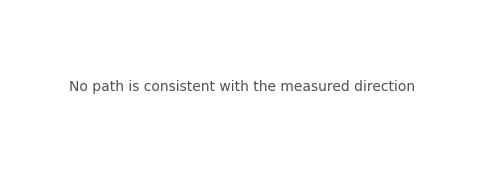

In [25]:
from transnet.visualization import plot_regulatory_paths

paths_figure = plot_regulatory_paths(traced_paths["WT"], graphs["WT"], top_n=8)
plt.show()

## The wiring

In [26]:
wiring = []
for genotype, graph in graphs.items():
    motifs = regulatory_motifs(graph, responsive_only=True)
    convergence = convergence_significance(graph, n_randomisations=200)
    vulnerability = structural_vulnerability(responsive_subnetwork(graph), top_n=5)
    wiring.append({
        "genotype": genotype,
        **{k: v for k, v in motifs["counts"].items()},
        "convergent reactions": convergence["observed"],
        "expected": round(convergence["null_mean"], 1),
        "z": round(convergence["z"], 1),
        "p": float(f"{convergence['p_value']:.3g}"),
        "holds it together": ", ".join(vulnerability["name"].head(2))
        if not vulnerability.empty else "",
    })
pd.DataFrame(wiring).set_index("genotype")

No responsive catalyst reaches any reaction: convergence is 0 by construction, not by measurement. This network has no measured Proteome layer, or none of its enzymes changed.


No responsive catalyst reaches any reaction: convergence is 0 by construction, not by measurement. This network has no measured Proteome layer, or none of its enzymes changed.


,product_inhibition,convergent reactions,expected,z,p,holds it together
genotype,,,,,,
WT,1,0,0.0,0.0,1.0,
ob/ob,2,0,0.0,0.0,1.0,


The convergence null, drawn. Wild-type liver has no proteome here, so the
enzyme side of a convergence is never measured and the count is 0 by
construction rather than by measurement.

No responsive catalyst reaches any reaction: convergence is 0 by construction, not by measurement. This network has no measured Proteome layer, or none of its enzymes changed.


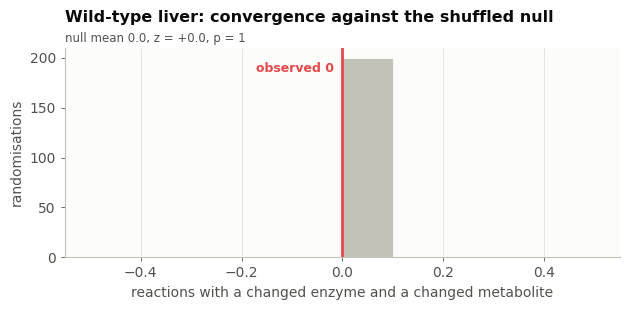

In [27]:
from transnet.visualization import (
    plot_convergence_null,
    plot_regulatory_motifs,
    plot_structural_vulnerability,
)

convergence_figure = plot_convergence_null(
    convergence_significance(graphs["WT"], n_randomisations=200),
    title="Wild-type liver: convergence against the shuffled null")
plt.show()

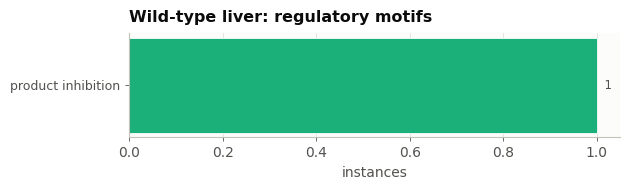

In [28]:
motif_figure = plot_regulatory_motifs(
    regulatory_motifs(graphs["WT"], responsive_only=True),
    title="Wild-type liver: regulatory motifs")
plt.show()

## The two genotypes as networks

In [29]:
comparison = compare_transomic_networks(
    responsive_subnetwork(graphs["WT"]), responsive_subnetwork(graphs["ob/ob"]),
    "WT", "ob/ob",
)
print(f"edge Jaccard between the two responses: "
      f"{comparison['summary']['edge_jaccard']:.2f}")
comparison["edges_by_type"]

edge Jaccard between the two responses: 0.00


,edge_type,n_WT,n_ob/ob,n_shared,gained_in_ob/ob,lost_in_ob/ob
0,allosteric_activation,144,0,0,0,144
1,allosteric_inhibition,346,0,0,0,346
2,product,70,1,1,0,69
3,substrate,109,1,1,0,108


In [30]:
comparison["nodes_by_layer"]

,layer,n_WT,n_ob/ob,n_shared,unique_to_WT,unique_to_ob/ob
0,Metabolome,22,2,2,20,0
1,Reactions,259,1,1,258,0


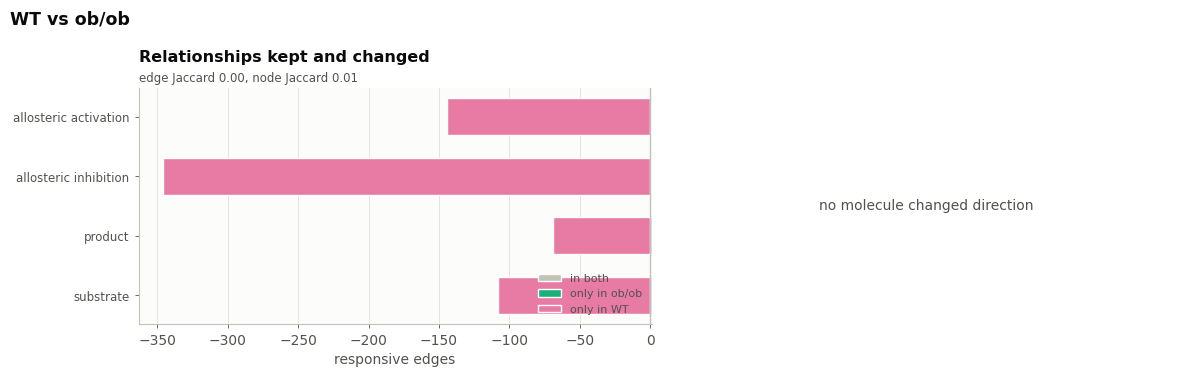

In [31]:
from transnet.visualization import plot_condition_comparison

comparison_figure = plot_condition_comparison(comparison, "WT", "ob/ob")
plt.show()

## The published claims, scored

The three claims `obese_liver.py` had to leave open, tested on the data they
were made from.

In [32]:
wt, obese = axes.loc["WT"], axes.loc["ob/ob"]
metabolite_share = {g: (row["metabolite only"] + row["both"]) / max(row["regulated"], 1)
                    for g, row in axes.iterrows()}
enzyme_share = {g: (row["enzyme only"] + row["both"]) / max(row["regulated"], 1)
                for g, row in axes.iterrows()}

claims = pd.DataFrame([
    {"claim": "Healthy hepatic glucose responses rely on regulation by metabolites",
     "evidence": f"{metabolite_share['WT']:.0%} of regulated reactions in WT "
                 f"carry a changed metabolite"},
    {"claim": "In ob/ob liver, regulation by metabolites is lost",
     "evidence": f"{metabolite_share['ob/ob']:.0%} in ob/ob against "
                 f"{metabolite_share['WT']:.0%} in WT; "
                 f"{obese['metabolite only'] + obese['both']} reactions against "
                 f"{wt['metabolite only'] + wt['both']}"},
    {"claim": "ob/ob glucose responses depend instead on slow gene expression",
     "evidence": f"{enzyme_share['ob/ob']:.0%} of ob/ob regulated reactions "
                 f"carry a changed transcript against {enzyme_share['WT']:.0%} "
                 f"in WT, over {len(contrasts['ob/ob']['Transcriptome']):,} genes"},
])
claims.to_csv(OUT / "published_claims.csv", index=False)
claims

,claim,evidence
0,Healthy hepatic glucose responses rely on regu...,34% of regulated reactions in WT carry a chang...
1,"In ob/ob liver, regulation by metabolites is lost",10% in ob/ob against 34% in WT; 88 reactions a...
2,ob/ob glucose responses depend instead on slow...,91% of ob/ob regulated reactions carry a chang...


## Figures

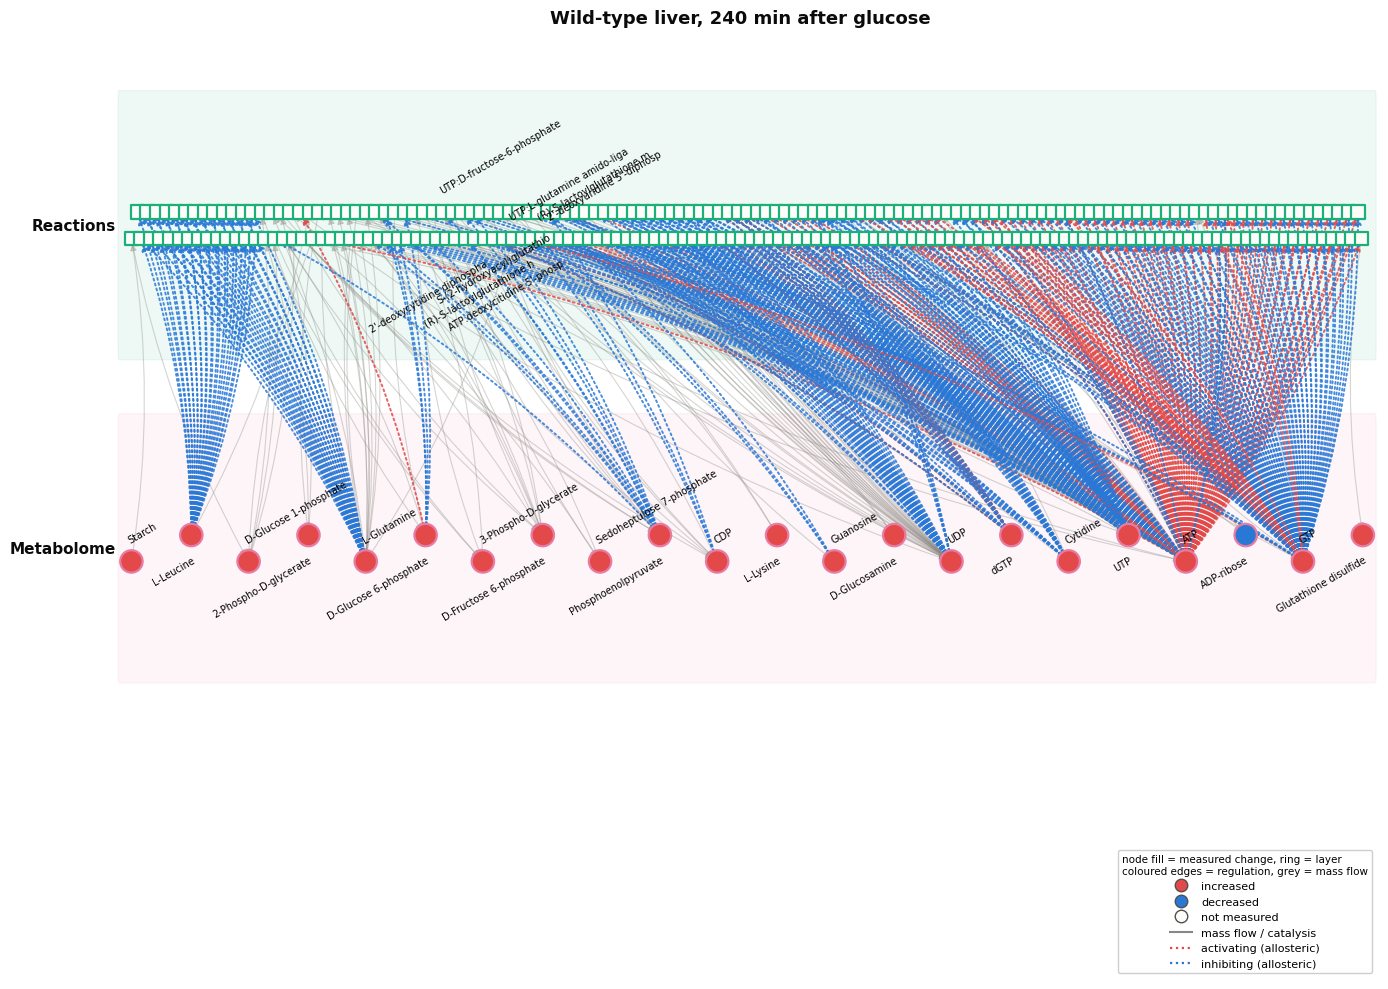

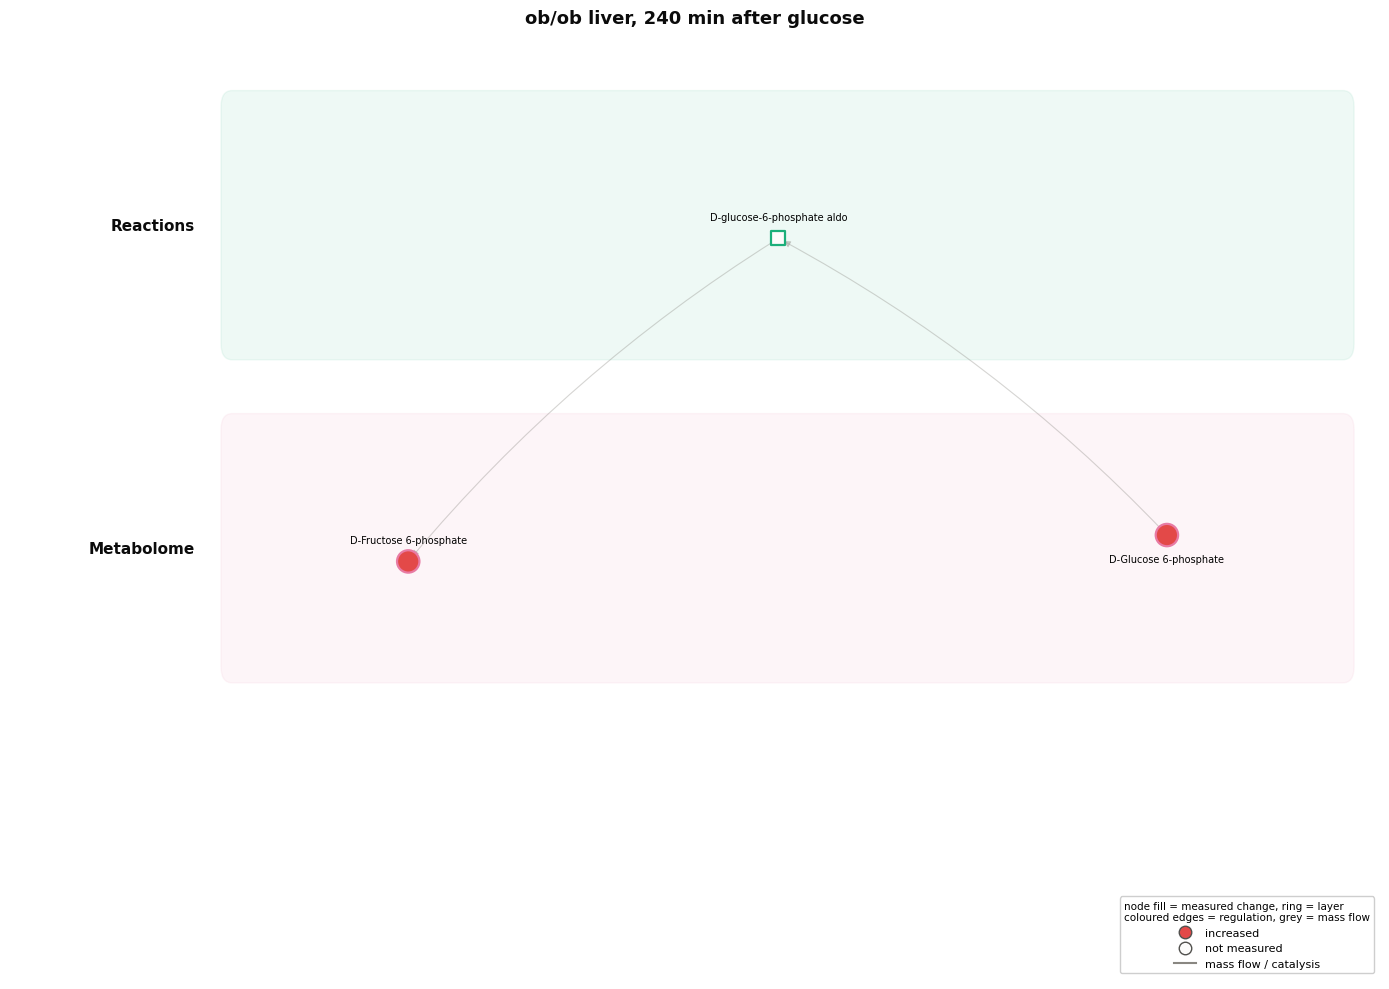

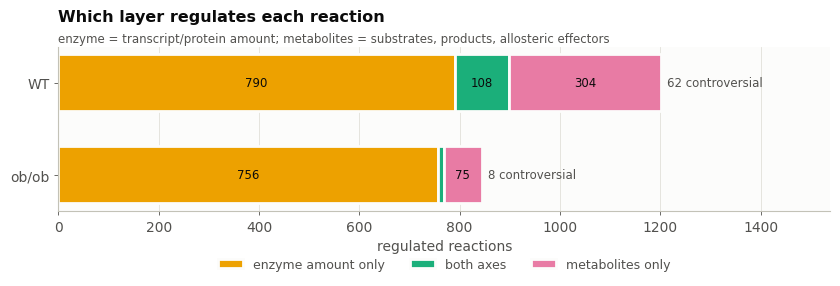

figures and tables in /Users/krv114/Documents/GitHub/transnet/data/published_results/kokaji_liver


In [33]:
from transnet.visualization import plot_transomic_network

for figure, name in [
    (plot_transomic_network(responsive_subnetwork(graphs["WT"]),
                            title="Wild-type liver, 240 min after glucose"),
     "network_WT"),
    (plot_transomic_network(responsive_subnetwork(graphs["ob/ob"]),
                            title="ob/ob liver, 240 min after glucose"),
     "network_obob"),
    (plot_axis_composition(composition), "axes_by_genotype"),
    (tf_figure, "tf_activity"),
    (regulator_figure, "metabolite_regulators"),
    (comparison_figure, "genotypes_compared"),
    (convergence_figure, "convergence_null"),
    (motif_figure, "regulatory_motifs"),
    (saturation_figure, "saturation"),
    (paths_figure, "regulatory_paths"),
]:
    figure.savefig(OUT / f"{name}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"figures and tables in {OUT}")